# **Muhammad Anas Nasir (FA23-BBD-086)**
# **Class: BDA-4A**
# **Course: Advanced Mathematics for Business Data Analytics**

----------

# **Code**

First 5 rows of the dataset:
   Feature_1  Feature_2  Feature_3  Feature_4  Feature_5    label
0   0.374540   0.950714   0.731994   0.598658   0.156019  Class B
1   0.155995   0.058084   0.866176   0.601115   0.708073  Class A
2   0.020584   0.969910   0.832443   0.212339   0.181825  Class A
3   0.183405   0.304242   0.524756   0.431945   0.291229  Class A
4   0.611853   0.139494   0.292145   0.366362   0.456070  Class A

Non-numeric columns:
Index(['label'], dtype='object')


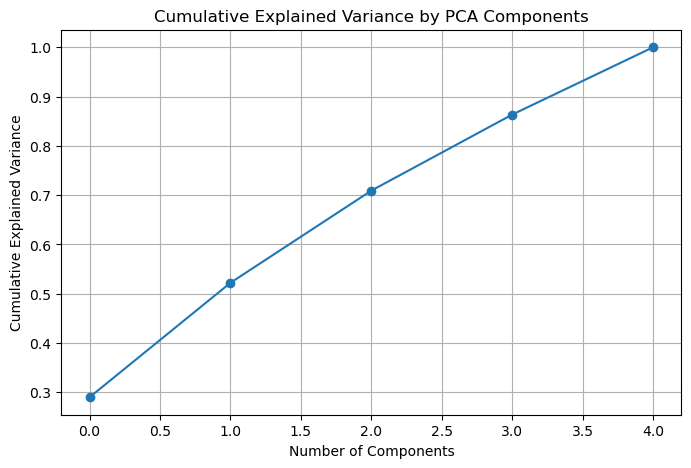

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load the dataset
df = pd.read_csv('csv_data.csv')

# Display the first few rows
print("First 5 rows of the dataset:")
print(df.head())

# Check for non-numeric columns
non_numeric_cols = df.select_dtypes(exclude=[np.number]).columns
print("\nNon-numeric columns:")
print(non_numeric_cols)

# Drop non-numeric columns for PCA
df_numeric = df.drop(columns=non_numeric_cols)

# Standardize the data
scaler = StandardScaler()
X_std = scaler.fit_transform(df_numeric)

# Apply PCA using scikit-learn
pca = PCA()
X_pca = pca.fit_transform(X_std)

# Plot the explained variance ratio
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()


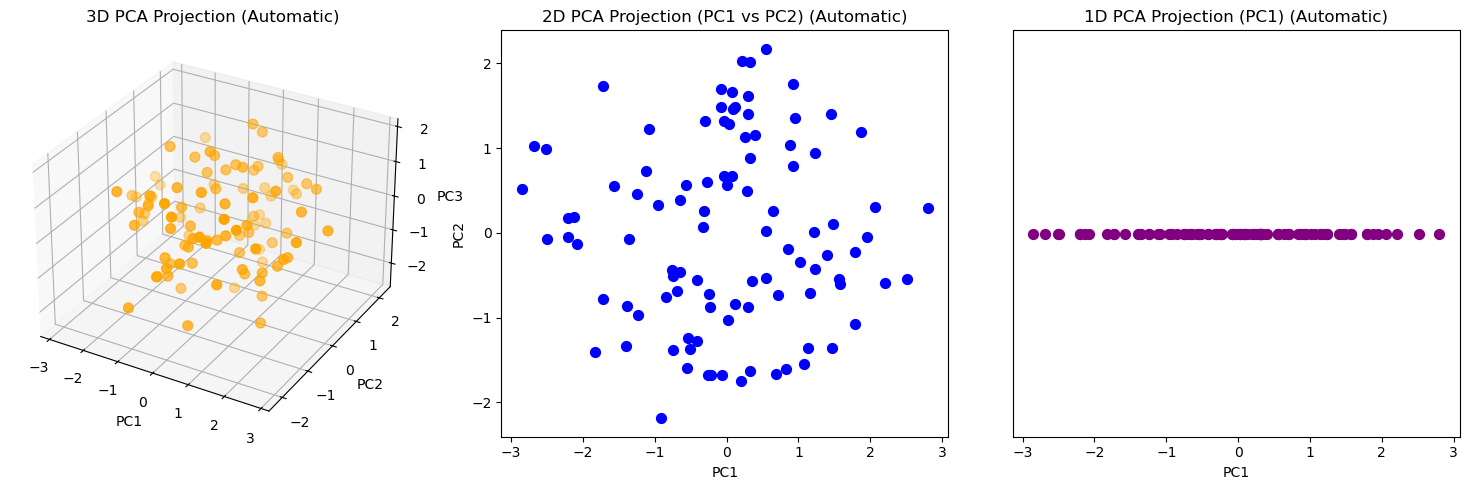

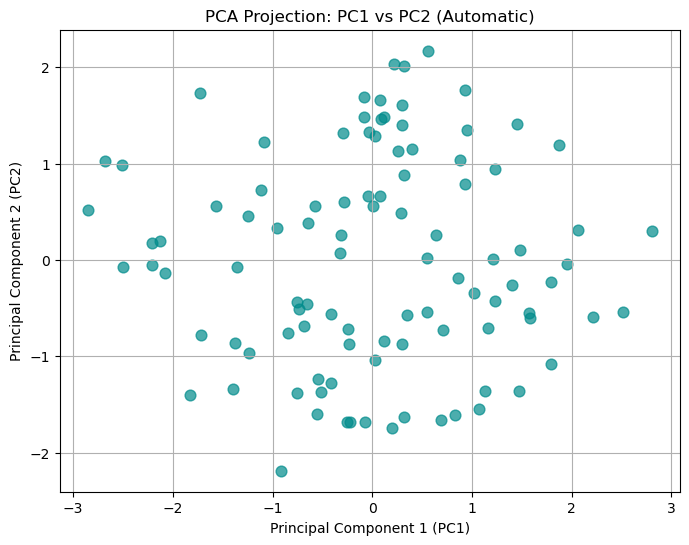

In [21]:
# -----------------------------------------
# Visualization for Automatic PCA (scikit-learn)
# -----------------------------------------

fig_auto = plt.figure(figsize=(15, 5))

# 3D Projection for Automatic PCA
ax_auto = fig_auto.add_subplot(131, projection='3d')
ax_auto.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c='orange', s=50)
ax_auto.set_title('3D PCA Projection (Automatic)')
ax_auto.set_xlabel('PC1')
ax_auto.set_ylabel('PC2')
ax_auto.set_zlabel('PC3')

# 2D Projection (PC1 vs PC2) for Automatic PCA
plt.subplot(132)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c='blue', s=50)
plt.title('2D PCA Projection (PC1 vs PC2) (Automatic)')
plt.xlabel('PC1')
plt.ylabel('PC2')

# 1D Projection (PC1) for Automatic PCA
plt.subplot(133)
plt.scatter(X_pca[:, 0], np.zeros_like(X_pca[:, 0]), c='purple', s=50)
plt.title('1D PCA Projection (PC1) (Automatic)')
plt.xlabel('PC1')
plt.yticks([])

plt.tight_layout()
plt.show()

# Additional standalone 2D PC1 vs PC2 plot for Automatic PCA
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c='darkcyan', s=60, alpha=0.7)
plt.title('PCA Projection: PC1 vs PC2 (Automatic)')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.grid(True)
plt.show()


# **Manual PCA 5 Step Code**

------


Explained Variance Ratios (Automatic PCA):
[0.29005782 0.23214006 0.18701323 0.15426411 0.13652477]

Eigenvalues (Manual PCA):
[1.46493849 1.17242457 0.94451127 0.77911166 0.68951906]

Eigenvectors (Manual PCA):
[[ 0.45026998 -0.5171464   0.15008625  0.56379839  0.43522642]
 [-0.44500468  0.11734679  0.79241243 -0.05412778  0.39667782]
 [-0.52043107  0.28542442 -0.28241803  0.75360655 -0.00127382]
 [ 0.45361733  0.44352316  0.47190465  0.32124815 -0.52117574]
 [ 0.35015797  0.66378418 -0.21703159 -0.08987964  0.61773692]]


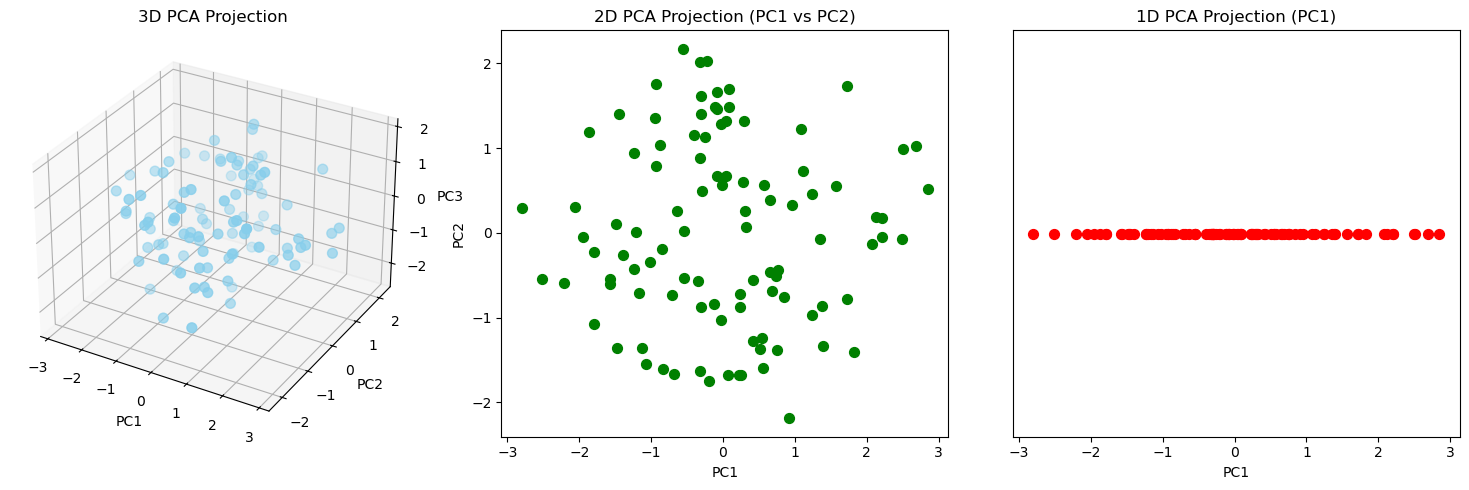

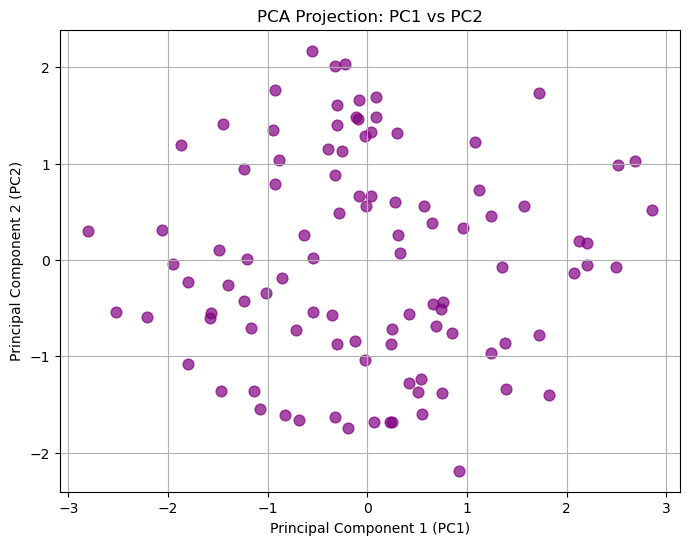

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

# Load your CSV dataset
df = pd.read_csv('csv_data.csv')

# Remove non-numeric or irrelevant columns (if any)
df_numeric = df.select_dtypes(include=[np.number])

# Step 1: Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)

# Step 2: Automatic PCA using scikit-learn
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print("\nExplained Variance Ratios (Automatic PCA):")
print(pca.explained_variance_ratio_)

# -----------------------------------------
# Manual PCA (5 steps)
# -----------------------------------------

# Step 1: Standardize already done above

# Step 2: Covariance matrix
cov_matrix = np.cov(X_scaled.T)

# Step 3: Eigen decomposition
eigen_values, eigen_vectors = np.linalg.eig(cov_matrix)

# Step 4: Sort eigenvectors by eigenvalues
sorted_idx = np.argsort(eigen_values)[::-1]
eigen_values = eigen_values[sorted_idx]
eigen_vectors = eigen_vectors[:, sorted_idx]

# Print eigenvalues and eigenvectors
print("\nEigenvalues (Manual PCA):")
print(eigen_values)

print("\nEigenvectors (Manual PCA):")
print(eigen_vectors)

# Step 5: Project data onto principal components
X_manual_pca = X_scaled.dot(eigen_vectors)

# -----------------------------------------
# Visualization
# -----------------------------------------

# 3D Projection
fig = plt.figure(figsize=(15, 5))
ax = fig.add_subplot(131, projection='3d')
ax.scatter(X_manual_pca[:, 0], X_manual_pca[:, 1], X_manual_pca[:, 2], c='skyblue', s=50)
ax.set_title('3D PCA Projection')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')

# 2D Projection (PC1 vs PC2)
plt.subplot(132)
plt.scatter(X_manual_pca[:, 0], X_manual_pca[:, 1], c='green', s=50)
plt.title('2D PCA Projection (PC1 vs PC2)')
plt.xlabel('PC1')
plt.ylabel('PC2')

# 1D Projection
plt.subplot(133)
plt.scatter(X_manual_pca[:, 0], np.zeros_like(X_manual_pca[:, 0]), c='red', s=50)
plt.title('1D PCA Projection (PC1)')
plt.xlabel('PC1')
plt.yticks([])

plt.tight_layout()
plt.show()

# Additional clear standalone plot for PC1 vs PC2 (Manual PCA)
plt.figure(figsize=(8,6))
plt.scatter(X_manual_pca[:, 0], X_manual_pca[:, 1], c='purple', s=60, alpha=0.7)
plt.title('PCA Projection: PC1 vs PC2')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.grid(True)
plt.show()
